

** Analista d'experiència del client: 

- Quins aspectes (precisió de detalls, higiene, check-in o
comunicació) presenten diferències més grans entre els allotjaments millor i pitjor valorats en
l'avaluació general?

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [21]:
df = pd.read_csv("../../Data/clean_data_16-03-2026.csv", parse_dates=['insert_date','first_review_date','last_review_date'])

df.columns

pd.set_option('display.max_columns', 40)

# Selecciono solo las columnas que nos interesan para visualizar más fácil

df[['apartment_id',
    'room_type', 
    'price',
    'number_of_reviews',
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value',
    'reviews_per_month',
    'city']]

,apartment_id,room_type,price,number_of_reviews,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,city
0,11964,Private room,400.0,78,97.0,100.0,100.0,100.0,100.0,100.0,100.0,75.0,Malaga
1,21853,Private room,170.0,33,92.0,90.0,90.0,100.0,100.0,80.0,90.0,52.0,Madrid
2,32347,Entire home/apt,990.0,148,98.0,100.0,100.0,100.0,100.0,100.0,100.0,142.0,Sevilla
3,35379,Private room,400.0,292,94.0,100.0,90.0,100.0,100.0,100.0,90.0,306.0,Barcelona
4,35801,Private room,900.0,36,97.0,100.0,100.0,100.0,100.0,100.0,100.0,39.0,Girona
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7688,32392193,Private room,3000.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Barcelona
7689,32392774,Entire home/apt,2090.0,36,100.0,100.0,100.0,100.0,100.0,100.0,100.0,157.0,Sevilla
7690,32395123,Entire home/apt,930.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mallorca
7691,32407332,Private room,960.0,21,98.0,100.0,100.0,100.0,100.0,100.0,100.0,389.0,Barcelona


Medias generales de las variables de calificación de alojamientos

In [22]:
df[['review_scores_rating', 
    'review_scores_accuracy',
    'review_scores_cleanliness', 
    'review_scores_checkin',
    'review_scores_communication']].mean().round(2)

review_scores_rating           91.94
review_scores_accuracy         94.55
review_scores_cleanliness      93.11
review_scores_checkin          96.27
review_scores_communication    96.35
dtype: float64

** Definir grupos usando percentiles.

- Top 25% → mejores alojamientos
- Bottom 25% → peores alojamientos

In [23]:
top = df[df["review_scores_rating"] >= df["review_scores_rating"].quantile(0.75)]
bottom = df[df["review_scores_rating"] <= df["review_scores_rating"].quantile(0.25)]

In [24]:
# Cálculo de medias
features = [
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication"
]

top_avg = top[features].mean()
bottom_avg = bottom[features].mean()

In [25]:
difference = (top_avg - bottom_avg).sort_values(ascending=False)

diff_df = pd.DataFrame({
    "Top listings": top_avg,
    "Bottom listings": bottom_avg,
    "Difference": difference
}).round(2)

print(diff_df)

                             Top listings  Bottom listings  Difference
review_scores_accuracy              99.03            85.90       13.13
review_scores_checkin               99.01            90.29        8.72
review_scores_cleanliness           98.31            84.34       13.98
review_scores_communication         99.26            90.13        9.12


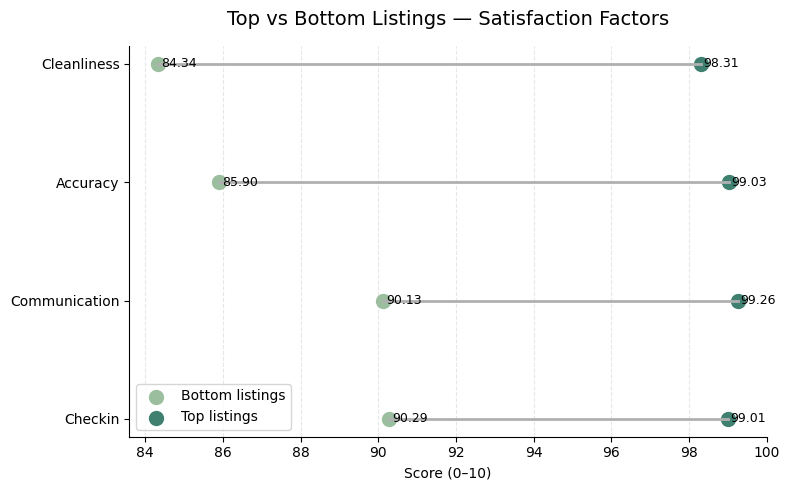

In [26]:

# 1. Crear grupos
top = df[df["review_scores_rating"] >= df["review_scores_rating"].quantile(0.75)]
bottom = df[df["review_scores_rating"] <= df["review_scores_rating"].quantile(0.25)]

# 2. Variables a comparar
features = [
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication"
]

# 3. Medias
top_avg = top[features].mean()
bottom_avg = bottom[features].mean()

# 4. DataFrame
dumbbell_df = pd.DataFrame({
    "Feature": features,
    "Top": top_avg.values,
    "Bottom": bottom_avg.values
})

# Limpiar nombres
dumbbell_df["Feature"] = dumbbell_df["Feature"].str.replace("review_scores_", "").str.capitalize()

# Ordenar por diferencia
dumbbell_df["diff"] = dumbbell_df["Top"] - dumbbell_df["Bottom"]
dumbbell_df = dumbbell_df.sort_values("diff")

# 5. Gráfico
plt.figure(figsize=(8,5))

# Líneas (dumbbell)
for i, row in dumbbell_df.iterrows():
    plt.plot(
        [row["Bottom"], row["Top"]],
        [row["Feature"], row["Feature"]],
        color="#b0b0b0",
        linewidth=2
    )

# Puntos
plt.scatter(
    dumbbell_df["Bottom"],
    dumbbell_df["Feature"],
    color="#9bbf9e",
    s=100,
    label="Bottom listings"
)

plt.scatter(
    dumbbell_df["Top"],
    dumbbell_df["Feature"],
    color="#3f8070",
    s=100,
    label="Top listings"
)

# Etiquetas valores
for i, row in dumbbell_df.iterrows():
    plt.text(row["Bottom"] + 1, row["Feature"], f"{row['Bottom']:.2f}", va="center", ha="right", fontsize=9)
    plt.text(row["Top"] + 0.05, row["Feature"], f"{row['Top']:.2f}", va="center", ha="left", fontsize=9)

plt.title("Top vs Bottom Listings — Satisfaction Factors", fontsize=14, pad=15)
plt.xlabel("Score (0–10)")
plt.ylabel("")

plt.legend()
plt.grid(axis="x", linestyle="--", alpha=0.3)

for spine in ["top","right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

Observar distribución

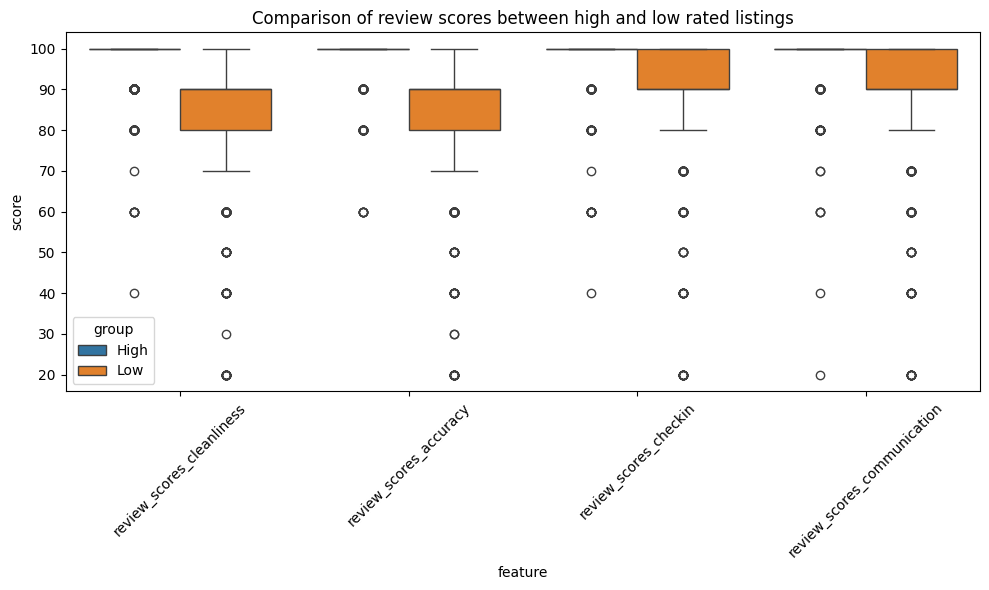

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

features = [
    'review_scores_cleanliness', 
    'review_scores_accuracy',
    'review_scores_checkin', 
    'review_scores_communication'
]

df_plot = df.copy()

q_low = df["review_scores_rating"].quantile(0.25)
q_high = df["review_scores_rating"].quantile(0.75)

df_plot['group'] = 'Mid'
df_plot.loc[df_plot['review_scores_rating'] <= q_low, 'group'] = 'Low'
df_plot.loc[df_plot['review_scores_rating'] >= q_high, 'group'] = 'High'

df_melt = df_plot[df_plot['group'] != 'Mid'].melt(
    id_vars='group', 
    value_vars=features,
    var_name='feature',
    value_name='score'
)

plt.figure(figsize=(10,6))
sns.boxplot(data=df_melt, x='feature', y='score', hue='group')

plt.title("Comparison of review scores between high and low rated listings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

los alojamientos buenos son casi todos perfectos en todas las caracteristicas (homogeneidad)

Los alojamientos bien valorados son muy homogéneos, mientras que los mal valorados presentan una gran variabilidad en sus puntuaciones (dispersion)

hay alojamientos con buena limpieza / accuracy que aun así tienen mala valoración general. (solapamiento)

--> Por lo tanto esto significa que altas puntuaciones en aspectos individuales tampoco no garantiza un promedio de puntuación alto.

Esto es para observar si hay alojamientos del cuartil inferior que a pesar de que tengan ratings al 100%, siguen teniendo un overall rating malo.

In [28]:
# La unica trampa de esto es que nos falta calidad_precio aqui (review_scores_value)

perfect_bot = bottom.loc[(bottom['review_scores_accuracy'] == 100) & (bottom['review_scores_cleanliness'] == 100) & (bottom['review_scores_checkin'] == 100) & (bottom['review_scores_communication'] == 100)]['apartment_id'].count()

almost_perfect_bot = bottom.loc[(bottom['review_scores_accuracy'] == 100) & (bottom['review_scores_cleanliness'] == 100)]['apartment_id'].count()

print('De los peores alojamientos, tienen todas las estadisticas perfectas:',perfect_bot, 'alojamientos' )
print('De los peores alojamientos, tienen accuracy y cleanliness perfectos:',almost_perfect_bot, 'alojamientos')

De los peores alojamientos, tienen todas las estadisticas perfectas: 50 alojamientos
De los peores alojamientos, tienen accuracy y cleanliness perfectos: 90 alojamientos


### Segmentaciones

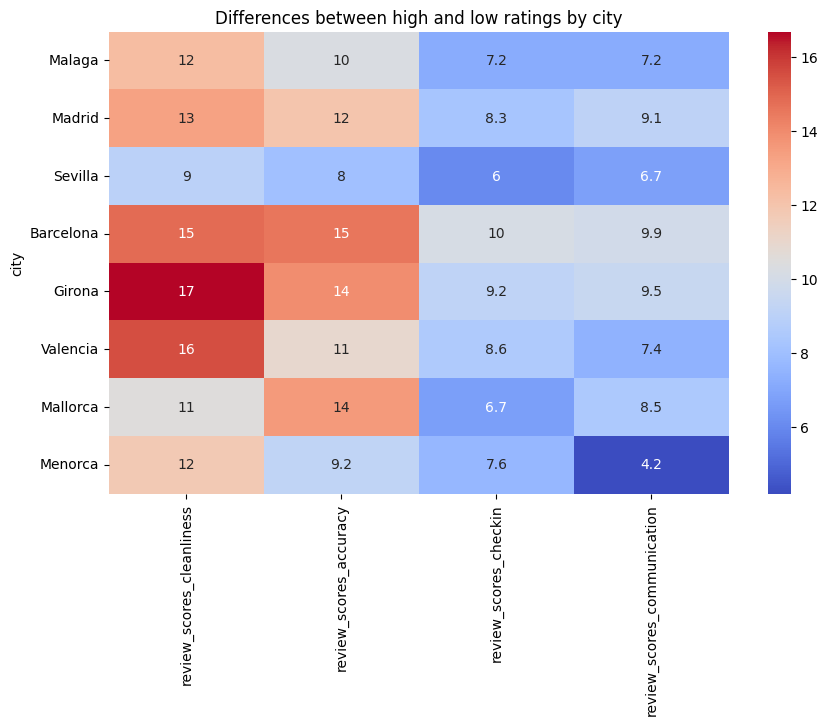

In [29]:
results = []

for city in df['city'].unique():
    df_city = df[df['city'] == city]
    
    q_low = df_city["review_scores_rating"].quantile(0.25)
    q_high = df_city["review_scores_rating"].quantile(0.75)
    
    low = df_city[df_city["review_scores_rating"] <= q_low]
    high = df_city[df_city["review_scores_rating"] >= q_high]
    
    diff = (high[features].mean() - low[features].mean())
    diff['city'] = city
    
    results.append(diff)

df_results = pd.DataFrame(results).set_index('city')

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df_results, annot=True, cmap="coolwarm")
plt.title("Differences between high and low ratings by city")
plt.show()

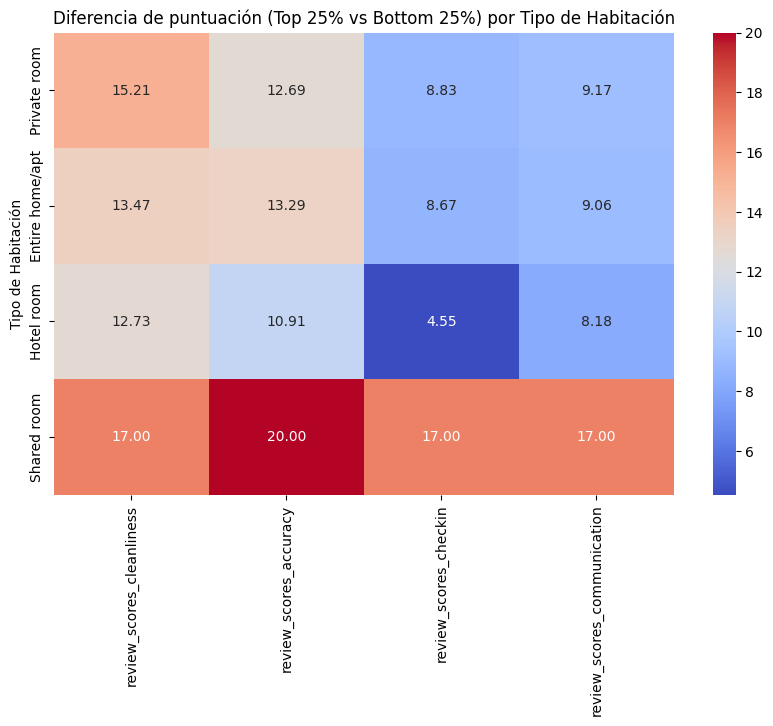

In [30]:
results = []

# Usamos 'tipo' para no confundir con la columna 'room_type'
for tipo in df['room_type'].unique():
    # Filtramos el dataframe para ese tipo de habitación
    df_tipo = df[df['room_type'] == tipo]
    
    # Calculamos los cuartiles para este grupo específico
    q_low = df_tipo["review_scores_rating"].quantile(0.25)
    q_high = df_tipo["review_scores_rating"].quantile(0.75)
    
    low = df_tipo[df_tipo["review_scores_rating"] <= q_low]
    high = df_tipo[df_tipo["review_scores_rating"] >= q_high]
    
    # Calculamos la diferencia de medias en las features
    # (Asegúrate de que 'features' esté definida antes)
    diff = (high[features].mean() - low[features].mean())
    
    # Guardamos el nombre del tipo de habitación para el índice
    diff.name = tipo 
    
    results.append(diff)

# Convertimos la lista de Series en un DataFrame
df_results = pd.DataFrame(results)

# Visualización
plt.figure(figsize=(10,6))
sns.heatmap(df_results, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Diferencia de puntuación (Top 25% vs Bottom 25%) por Tipo de Habitación")
plt.ylabel("Tipo de Habitación")
plt.show()

## Correlaciones

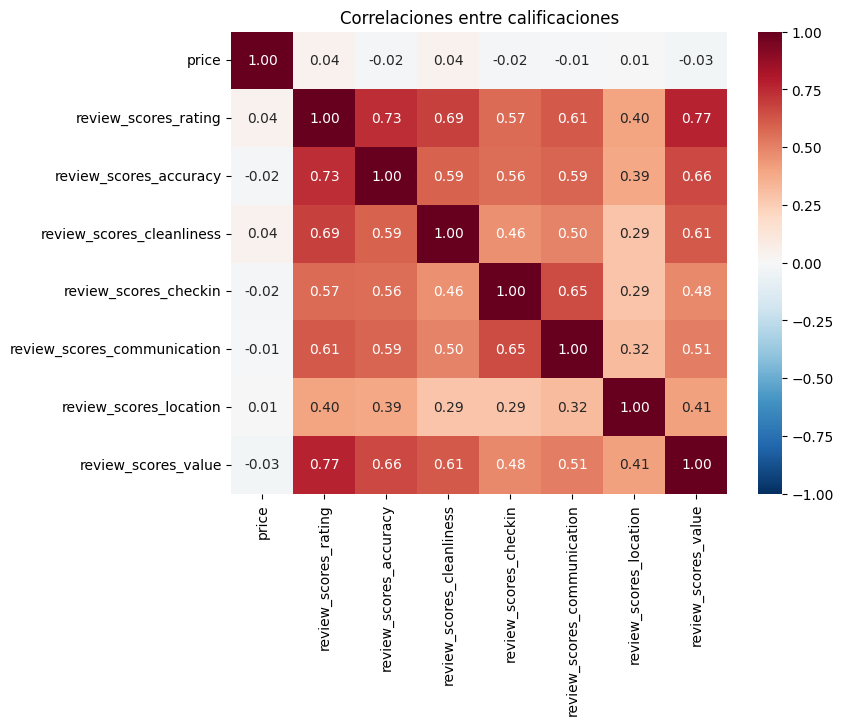

In [31]:
df_corr = df[['price','review_scores_rating', 'review_scores_accuracy','review_scores_cleanliness', 'review_scores_checkin','review_scores_communication', 'review_scores_location','review_scores_value']] # 'reviews_per_month','number_of_reviews'

plt.figure(figsize=(8,6))
sns.heatmap(df_corr.corr(), cmap= 'RdBu_r', annot=True, fmt=".2f", vmin=-1, vmax=1, center=0)
plt.title("Correlaciones entre calificaciones")
plt.show()


Este gráfico es para observar las relaciones entre categorías de calificación. Todas ellas mantienen correlaciones, más o menos elevadas.

Qué correlaciones existen entre calificación general y calificaciones específicas?

Existe un efecto contagio? A veces, cuando un cliente se enfada por algun motivo, castiga el resto de categorías, y viceversa.

- Limpieza y accuracy son las variables más importantes para la calificación general (0.7)
- Communication y check-in van de la mano (correlación entre ellas)

- Price y review_scores no muestra correlación (0), con lo cual mayor precio no garantiza mayor rating ni menor rating. El precio y la calidad percibida no correlacionan.

*Insight y propuestas de negocio*

Obviando el precio y la ubicación, el éxito de StaySpain descansa sobre dos pilares: la higiene y la honestidad.

- La limpieza es un pilar fundamental. Un alojamiento puede estar lejos o ser sencillo, pero si está impecable, la nota general sube.
    - Programas de limpieza para garantizar o verificar estándares mínimos.
    - Anfitriones utilicen empresas de limpieza profesionales.

- El accuracy, más importante todavía. El Accuracy mide la brecha entre la expectativa (fotos/descripción) y la realidad. 
    - No debemos 'sobre-vender' los alojamientos en las fotos de la plataforma.
    - Sistema de verificación de inventario.

### Random Forest Regression

In [32]:
features = [ 
    'review_scores_cleanliness', 
    'review_scores_accuracy',
    'review_scores_checkin', 
    'review_scores_communication'
]

df_ml = df.dropna(subset=features + ['review_scores_rating'])

X = df_ml[features]
y = df_ml['review_scores_rating']

In [33]:
# Train/test

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [34]:
rf = RandomForestRegressor(
    n_estimators=2000,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",2000
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [35]:
# 4. Extraer la importancia de las variables
importances = rf.feature_importances_
feature_names = [f.replace('review_scores_', '').capitalize() for f in features]
forest_importances = pd.Series(importances, index=feature_names).sort_values(ascending=True)

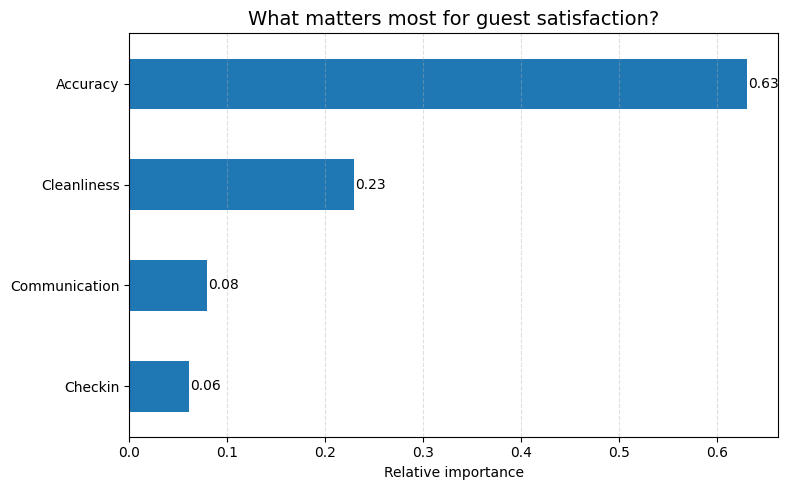

In [36]:
# 5. Visualización
plt.figure(figsize=(8, 5))

forest_importances.sort_values().plot(kind='barh')

plt.title("What matters most for guest satisfaction?", fontsize=14)
plt.xlabel("Relative importance")

for i, v in enumerate(forest_importances.sort_values()):
    plt.text(v + 0.001, i, f"{v:.2f}", va='center')

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Cleanliness and accuracy are both strongly related to overall rating, but they share a significant amount of information. The model prioritizes accuracy as the most efficient predictor.

Pero NO significa que accuracy sea más importante.

In [37]:
# Evaluación del modelo. 3.31 puntos de rating de error. El modelo explica el 55% de la variabilidad del rating (la mitad)

from sklearn.metrics import mean_absolute_error, r2_score

y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"R2: {r2:.2f}")

MAE: 3.22
R2: 0.69


In [38]:
from sklearn.inspection import permutation_importance

result = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)

pd.Series(result.importances_mean, index=X.columns).sort_values()

review_scores_checkin          0.026126
review_scores_communication    0.081865
review_scores_cleanliness      0.249200
review_scores_accuracy         0.418222
dtype: float64

Both accuracy and cleanliness play a key role in explaining overall ratings, with accuracy showing a slightly stronger effect. However, the relatively close importance values suggest that both variables capture overlapping aspects of guest satisfaction.

### Threshold

In [41]:
gap_table_presentacion = gap_table.copy()

gap_table_presentacion.index = [
    "Accuracy",
    "Cleanliness",
    "Check-in",
    "Communication"
]

print(gap_table_presentacion.round(2))

               mean_P25  mean_P75    gap
Accuracy          84.44     98.32  13.88
Cleanliness       85.90     99.02  13.13
Check-in          90.15     99.26   9.11
Communication     90.35     99.01   8.66


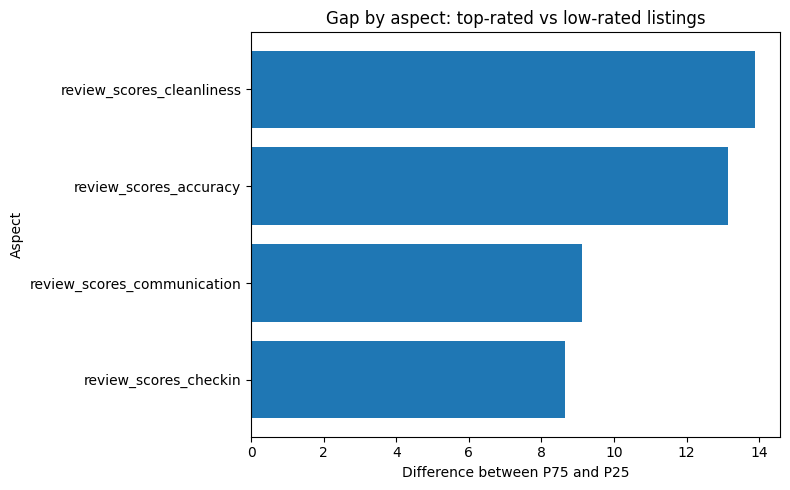

In [42]:
import matplotlib.pyplot as plt

gap_plot = gap_table.sort_values("gap", ascending=True)

plt.figure(figsize=(8,5))
plt.barh(gap_plot.index, gap_plot["gap"])
plt.xlabel("Difference between P75 and P25")
plt.ylabel("Aspect")
plt.title("Gap by aspect: top-rated vs low-rated listings")
plt.tight_layout()
plt.show()

** Impacto potencial de mejora
- Regresión lineal:
Esto estima cuánto cambia el review_scores_rating cuando mejora cada aspecto.

In [44]:
from sklearn.linear_model import LinearRegression

# Dataset limpio para regresión
df_reg = df[[rating_col] + aspect_cols].dropna().copy()

X = df_reg[aspect_cols]
y = df_reg[rating_col]

# Modelo
model = LinearRegression()
model.fit(X, y)

# Coeficientes
coef_table = pd.DataFrame({
    "aspect": aspect_cols,
    "coefficient": model.coef_
}).sort_values("coefficient", ascending=False)

intercept = model.intercept_
r2 = model.score(X, y)

print("Intercept:", round(intercept, 3))
print("R²:", round(r2, 3))
print("\nCoeficientes:")
print(coef_table.round(2))

Intercept: 2.531
R²: 0.667

Coeficientes:
                        aspect  coefficient
0       review_scores_accuracy         0.38
1    review_scores_cleanliness         0.30
3  review_scores_communication         0.18
2        review_scores_checkin         0.09


Interpretación de coeficientes

Manteniendo constantes el resto de variables, un aumento de 1 punto en cleanliness se asocia con un incremento de 0.30 puntos en el rating general.


El impacto existe, pero es moderado
No es un driver dominante por sí solo
Necesitamos mejorar varios aspectos para ver un cambio relevante en el rating

Estimar impacto potencial cerrando la brecha
Ahora combinamos ambas cosas:
gap entre P25 y P75
coeficiente de la regresión


In [46]:
# Unir gaps y coeficientes
impact_table = gap_table.reset_index().rename(columns={"index": "aspect"})
impact_table = impact_table.merge(coef_table, on="aspect", how="left")

# Impacto potencial estimado
impact_table["estimated_rating_impact"] = impact_table["gap"] * impact_table["coefficient"]

# Ordenar de mayor impacto a menor
impact_table = impact_table.sort_values("estimated_rating_impact", ascending=False)

print("\nImpacto potencial estimado:")
print(impact_table.round(2))


Impacto potencial estimado:
                        aspect  mean_P25  mean_P75    gap  coefficient  \
1       review_scores_accuracy     85.90     99.02  13.13         0.38   
0    review_scores_cleanliness     84.44     98.32  13.88         0.30   
2  review_scores_communication     90.15     99.26   9.11         0.18   
3        review_scores_checkin     90.35     99.01   8.66         0.09   

   estimated_rating_impact  
1                     4.94  
0                     4.14  
2                     1.67  
3                     0.76  


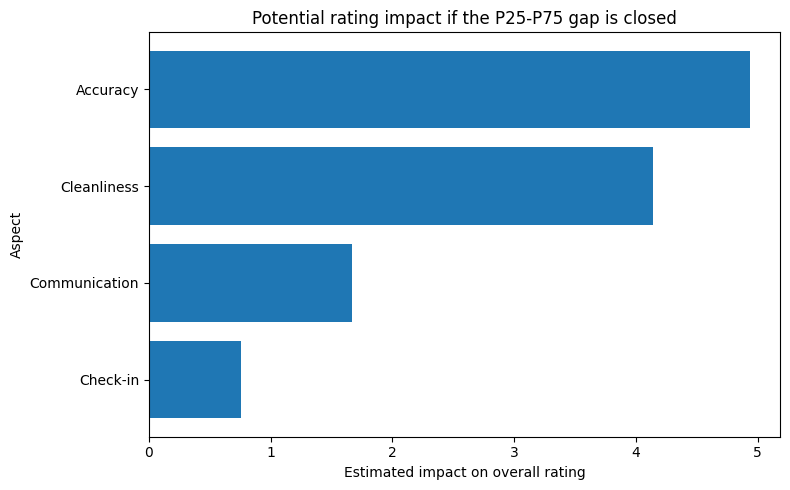

In [48]:
impact_plot = impact_table_presentacion.sort_values("estimated_rating_impact", ascending=True)

plt.figure(figsize=(8,5))
plt.barh(impact_plot["aspect"], impact_plot["estimated_rating_impact"])
plt.xlabel("Estimated impact on overall rating")
plt.ylabel("Aspect")
plt.title("Potential rating impact if the P25-P75 gap is closed")
plt.tight_layout()
plt.show()

- El gap analysis es descriptivo
- La regresión muestra asociación, no causalidad
- El “impacto potencial” es una estimación, no una garantía real

In [50]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

df_std = df[[rating_col] + aspect_cols].dropna().copy()

X = df_std[aspect_cols]
y = df_std[rating_col]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model_std = LinearRegression()
model_std.fit(X_scaled, y)

coef_std_table = pd.DataFrame({
    "aspect": aspect_cols,
    "standardized_coefficient": model_std.coef_
}).sort_values("standardized_coefficient", ascending=False)

print(coef_std_table.round(2))

                        aspect  standardized_coefficient
0       review_scores_accuracy                      3.50
1    review_scores_cleanliness                      2.97
3  review_scores_communication                      1.46
2        review_scores_checkin                      0.70


In [52]:
# gap + coeficiente para sacar una priorización accionable.
coef_table = coef_table.rename(columns={"aspect": "aspect"})

impact_table = gap_table.reset_index().rename(columns={"index": "aspect"})
impact_table = impact_table.merge(coef_table, on="aspect", how="left")

# Impacto potencial
impact_table["estimated_rating_impact"] = (
    impact_table["gap"] * impact_table["coefficient"]
)

# Orden final
impact_table = impact_table.sort_values("estimated_rating_impact", ascending=False)

impact_table.round(3)

,aspect,mean_P25,mean_P75,gap,coefficient,estimated_rating_impact
1,review_scores_accuracy,85.897,99.023,13.126,0.376,4.937
0,review_scores_cleanliness,84.442,98.319,13.878,0.298,4.140
2,review_scores_communication,90.147,99.255,9.108,0.183,1.670
3,review_scores_checkin,90.351,99.011,8.660,0.088,0.759


Interpretación en 4 categorias:

| Caso                            | Qué significa                     | Acción                     |
| ------------------------------- | --------------------------------- | -------------------------- |
| **Alto gap + alto coeficiente** | Gran diferencia + alto impacto    | 🔴 PRIORIDAD MÁXIMA        |
| Alto gap + bajo coeficiente     | Se ve mucho pero influye poco     | 🟡 Mejora secundaria       |
| Bajo gap + alto coeficiente     | No diferencia ahora pero es clave | 🟠 Oportunidad estratégica |
| Bajo gap + bajo coeficiente     | Poco relevante                    | ⚪ Baja prioridad           |


In [54]:
# Normalizar para comparar 
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

impact_table[["gap_norm", "coef_norm"]] = scaler.fit_transform(
    impact_table[["gap", "coefficient"]]
)

# Score combinado
impact_table["priority_score"] = (
    impact_table["gap_norm"] * 0.5 + impact_table["coef_norm"] * 0.5
)

impact_table = impact_table.sort_values("priority_score", ascending=False)

impact_table.round(2)

,aspect,mean_P25,mean_P75,gap,coefficient,estimated_rating_impact,gap_norm,coef_norm,priority_score
1,review_scores_accuracy,85.90,99.02,13.13,0.38,4.94,0.86,1.00,0.93
0,review_scores_cleanliness,84.44,98.32,13.88,0.30,4.14,1.00,0.73,0.87
2,review_scores_communication,90.15,99.26,9.11,0.18,1.67,0.09,0.33,0.21
3,review_scores_checkin,90.35,99.01,8.66,0.09,0.76,0.00,0.00,0.00


- PRIORIDAD MÁXIMA — Accuracy
Mayor impacto estimado: +4.94 puntos
Alto gap (13.13)
Mayor coeficiente (0.38)
Priority score: 0.93
- Conclusión: Es el principal driver. La precisión de la información es el factor que más explica por qué unos alojamientos están mejor valorados que otros.

- PRIORIDAD ALTA — Cleanliness
Impacto estimado: +4.14 puntos
Mayor gap (13.88)
Alto coeficiente (0.30)
Priority score: 0.87
- Conclusión: La limpieza es el segundo gran factor de diferenciación y tiene un impacto significativo en la valoración.

- PRIORIDAD MEDIA — Communication
Impacto estimado: +1.67
Gap moderado (9.11)
Coeficiente medio (0.18)
Priority score: 0.21
- Conclusión: Mejora la experiencia, pero no es un driver principal del rating.

- BAJA PRIORIDAD — Check-in
Impacto estimado: +0.76
Gap bajo
Coeficiente muy bajo (0.09)
Priority score: 0.00
- Conclusión: No es un factor relevante para explicar diferencias en la valoración general.

- Este enfoque permite pasar de un análisis descriptivo a una priorización basada en impacto, facilitandonos la toma de decisiones operativas.